<a href="https://colab.research.google.com/github/shehlagullofficial/Customer-Personality-Analysis/blob/main/Customer_Personality_Analysis_Python_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Portfolio Project 2:



# Customer Personality Ananlysis

## Overview of Data Set:

---





1.The dataset contains customer information such as demographics (age, education, marital status), purchasing behavior (spending and purchases), and responses to marketing campaigns.

#### Key variables :

*   Demographics → Age,Education, Marital Status, Income
*  Behavior → Total Spending, Purchases  
*   Campaign → AcceptedCmp1–5
*   Family → Kidhome, Teenhome (Child_Type)











# Data Dictionary

---

| # | Column Name | Category | Data Type | Description |
|---|-------------|----------|-----------|-------------|
| 1 | `ID` | Demographics | int | Unique customer identifier |
| 2 | `Year_Birth` | Demographics | int | Customer's year of birth |
| 3 | `Education` | Demographics | str | Highest education level achieved |
| 4 | `Marital_Status` | Demographics | str | Customer's marital status |
| 5 | `Income` | Demographics | float | Annual household income (USD) |
| 6 | `Dt_Customer` | Demographics | date | Date customer enrolled in the programme |
| 7 | `Recency` | Purchase Behaviour | int | Days since the customer's last purchase |
| 8 | `MntWines` | Spending | int | Amount spent on wine products (USD) |
| 9 | `MntFruits` | Spending | int | Amount spent on fruit products (USD) |
| 10 | `MntMeatProducts` | Spending | int | Amount spent on meat products (USD) |
| 11 | `MntFishProducts` | Spending | int | Amount spent on fish products (USD) |
| 12 | `MntSweetProducts` | Spending | int | Amount spent on sweets (USD) |
| 13 | `MntGoldProds` | Spending | int | Amount spent on gold/luxury products (USD) |
| 14 | `NumDealsPurchases` | Purchase Channels | int | Purchases made using discounts |
| 15 | `NumWebPurchases` | Purchase Channels | int | Purchases made through the website |
| 16 | `NumCatalogPurchases` | Purchase Channels | int | Purchases made via catalogue |
| 17 | `NumStorePurchases` | Purchase Channels | int | Purchases made in-store |
| 18 | `NumWebVisitsMonth` | Purchase Channels | int | Website visits in the last month |
| 19 | `AcceptedCmp1` | Campaigns | binary | Accepted Campaign 1 (1 = Yes, 0 = No) |
| 20 | `AcceptedCmp2` | Campaigns | binary | Accepted Campaign 2 (1 = Yes, 0 = No) |
| 21 | `AcceptedCmp3` | Campaigns | binary | Accepted Campaign 3 (1 = Yes, 0 = No) |
| 22 | `AcceptedCmp4` | Campaigns | binary | Accepted Campaign 4 (1 = Yes, 0 = No) |
| 23 | `AcceptedCmp5` | Campaigns | binary | Accepted Campaign 5 (1 = Yes, 0 = No) |
| 24 | `Response` | Campaigns | binary | Accepted the final campaign (1 = Yes, 0 = No) |
| 25 | `Complain` | Campaigns | binary | Customer filed a complaint in the last 2 years |
| 26 | `Kidhome` | Family | int | Number of young children at home |
| 27 | `Teenhome` | Family | int | Number of teenagers at home |
| 28 | `Z_CostContact` | Dropped Columns | int | Constant cost-of-contact column |
| 29 | `Z_Revenue` | Dropped Columns | int | Constant revenue column |
| — | `Age` | Engineered | int | Customer age derived from Year_Birth |
| — | `AgeGroup` | Engineered | str | Age bucket used for segmentation |
| — | `Total_Spending` | Engineered | int | Sum of all product spending columns |
| — | `Total_purchases` | Engineered | int | Total purchases across all channels |
| — | `Total_Childerns` | Engineered | int | Total number of children and teenagers at home |
| — | `Campaign_Accepted` | Engineered | int | Total campaigns accepted by the customer |
| — | `Customer_Tenure_Days` | Engineered | int | Days since customer enrollment |
| — | `CLV` | Engineered | float | Customer Lifetime Value |
| — | `Income_Group` | Engineered | str | Income quartile category |

# Business Questions


---


1.   Who are our most valuable customers, and what makes them spend more?

2.   Which marketing campaigns are actually working?

3.   Which sales channel should the company invest in more?

4.   Do customers with children behave differently than those without?

5.  Which products drive the most revenue, and which customer groups buy them?



 SECTION 0: IMPORT LIBRARIES


In [2]:
# Importing Libararies

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

In [46]:
del plt.title

In [47]:
import importlib
importlib.reload(plt)

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

In [49]:
print(type(plt.title))

<class 'function'>


# SECTION 1: LOAD &  LOOK AT THE DATA


In [6]:
df = pd.read_csv('marketing_campaign.csv', sep='\\t')
df.head(5)

,"""ID",Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,"Response"""
0,"""5524",1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,"1"""
1,"""2174",1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,"0"""
2,"""4141",1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,"0"""
3,"""6182",1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,"0"""
4,"""5324",1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,"0"""


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   "ID                  2240 non-null   object 
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [8]:
df.describe()

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue
count,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0
mean,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,...,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0
std,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,...,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0
min,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0
25%,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,...,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0
50%,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,...,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0
75%,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,...,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0
max,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,...,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0


In [7]:
df.columns

Index(['"ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response"'],
      dtype='object')

In [9]:
df.duplicated().sum()

np.int64(0)

#To Check missing Values

In [ ]:
df.isnull().sum()

,0
"""ID",0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [ ]:
missing = df.isnull().sum()   # Count missing values in each column

px.bar(                        #start creating a bar
    x=missing.index,      # Show column names on x-axis
    y=missing.values,     # Show missing values count on y-axis
    title="Missing Values" #Graph title
).show()

# SECTION 2: DATA CLEANING


## Replacing Missing Values


In [10]:
#Replacing Missing Values in Income Column

df['Income'] = df.groupby('Education')['Income'] \
    .transform(lambda x: x.fillna(x.median()))

# PhD missing income → filled with PhD group median (~$60K)
# Basic missing income → filled with Basic group median (~$20K)
# Much more .....

In [11]:
print("Missing values in Income:", df['Income'].isnull().sum())

Missing values in Income: 0


## Removing Useless Columns


In [12]:
#Removing 2 useless Coulmns('Z_CostContact', 'Z_Revenue)

df = df.drop(columns=['Z_CostContact', 'Z_Revenue'])
print("\nDropped 2 useless columns")


Dropped 2 useless columns


In [13]:
import datetime

## FEATURE ENGINEERING


### Calculating Age

In [14]:
#Creating New Coulmn to calculate "Age" from 2014 year

df['Age'] = 2015 - df['Year_Birth']

### Total Spendings

In [15]:
#Total spending across all product categories

df['Total_Spending'] = (df['MntWines']+ df['MntFruits']+df['MntFishProducts']+df['MntSweetProducts']+df['MntMeatProducts']+df['MntGoldProds'])

### Total Purchases

In [16]:
#Adding total Purcahses

df['Total_purchases'] = (df['NumCatalogPurchases']+df['NumDealsPurchases']+df['NumStorePurchases']+df['NumWebPurchases'])

### Number of Children

In [17]:
# Total children at home

df['Total_Childerns'] = (df['Kidhome'] + df['Teenhome'])

### Adding all Campaigns

In [18]:
# Adding up all Campaigns

df['Campaign_Accepted'] = (df['AcceptedCmp1']+df['AcceptedCmp2']+df['AcceptedCmp3']+df['AcceptedCmp4']+df['AcceptedCmp5'])

### Checking for Marital Status Values

In [19]:
df["Marital_Status"].value_counts()

,count
Marital_Status,
Married,864
Together,580
Single,480
Divorced,232
Widow,77
Alone,3
Absurd,2
YOLO,2


### Replacing "Absurd", "Alone", and "YOLO"

In [20]:
#Replacing (Absurd, Alone and YOLO with "Single")

df["Marital_Status"] = df["Marital_Status"].replace({

    "Absurd": "Single",
    "Alone": "Single",
   "YOLO" : "Single",
})

In [21]:
df["Marital_Status"].value_counts()

,count
Marital_Status,
Married,864
Together,580
Single,487
Divorced,232
Widow,77


In [22]:
print(df["Education"].value_counts())

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64


### Creating Age Groups

In [23]:
# Customer Age Group (for segmentation)

df["AgeGroup"] = pd.cut(df["Age"], bins=[17, 30, 45, 60, 90],
                         labels=["Young (18-30)", "Adult (31-45)",
                                 "Mature Adult (46-60)", "Elder (61+)"])

### Customer tenure

In [24]:
# Customer tenure in days (Dt_Customer → days since joining)

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)
reference_date = pd.Timestamp("2014-12-31")
df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

## 2C. OUTLIER CHECK


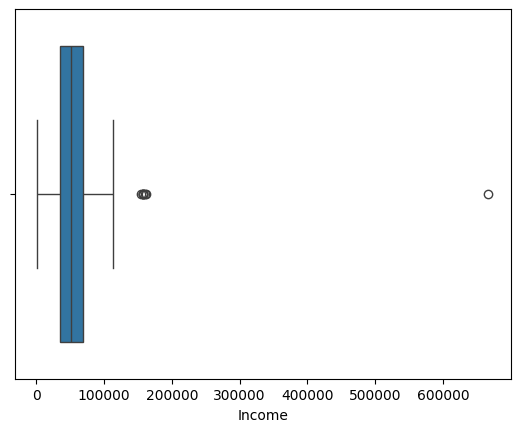

In [ ]:
sns.boxplot(x=df["Income"])         #Income has extreme outlier ($666,666)
plt.show()

In [26]:
df_ml = df.copy()

### Checking how extreme it is

In [ ]:
df_ml['Income'].sort_values(ascending=False).head(10)

,Income
2233,666666.0
617,162397.0
687,160803.0
1300,157733.0
164,157243.0
1653,157146.0
2132,156924.0
655,153924.0
1898,113734.0
646,105471.0


### Replace with Median Value

In [27]:
median_income = df_ml['Income'].median()
print("Median Income:", median_income)

Median Income: 51498.5


### Age Outlier

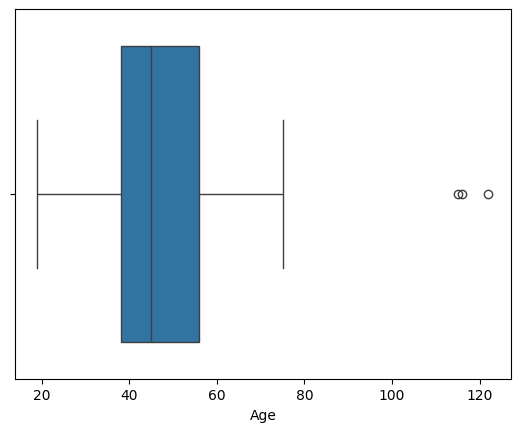

In [ ]:
sns.boxplot(x=df["Age"])            #Age has extreme outlier (130 age)
plt.show()

#### Removing Age Outlier

In [28]:
df = df[df.Age < 100]       # Remove unrealistic age values


## Customer Distribution by Marital Status

In [29]:
# Count values of marital status
marital_status_counts = df['Marital_Status'].value_counts()

# Store title in a separate variable
chart_title = "Customer Distribution by Marital Status"

# Create Pie Chart
fig = px.pie(
    values=marital_status_counts.values,
    names=marital_status_counts.index,
    color_discrete_sequence=px.colors.sequential.Blues_r
)

# Add title separately (safer method)
fig.update_layout(
    title_text=chart_title
)

# Styling
fig.update_traces(
    textposition='inside',
    textinfo='percent+label',
    marker=dict(
        line=dict(color='white', width=4)
    )
)

# Show chart
fig.show()

## Customer Age Group Distribution

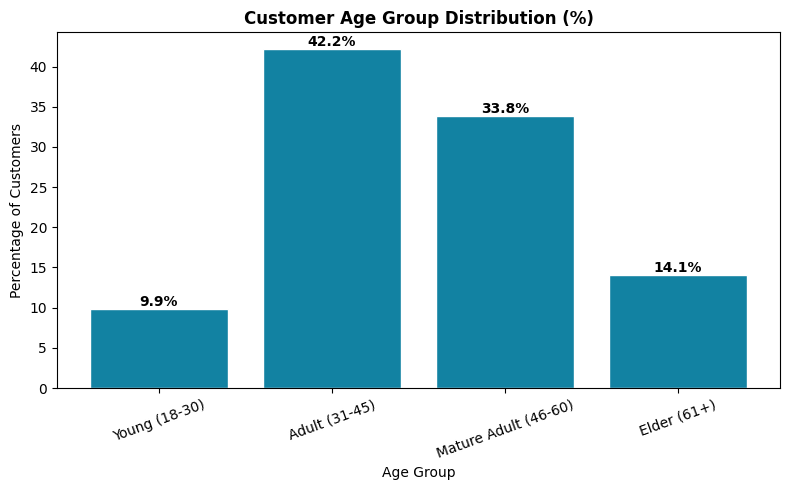

In [30]:
age_pct = df["AgeGroup"].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(8,5))

bars = plt.bar(age_pct.index, age_pct.values, color='#1282a2', edgecolor='white')

plt.title("Customer Age Group Distribution (%)", fontsize=12, fontweight='bold')
plt.xlabel("Age Group")
plt.ylabel("Percentage of Customers")

plt.xticks(rotation=20)

# Add percentages on bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():.1f}%',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

## Average Spending by Child Status

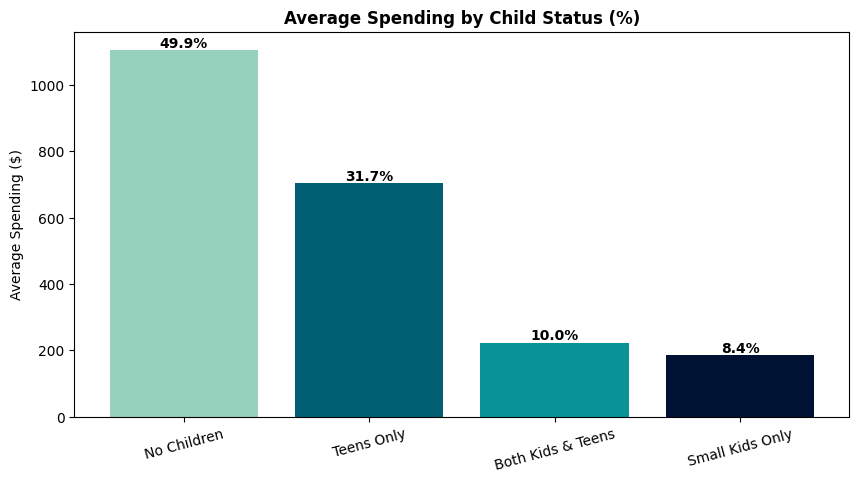

In [31]:
import matplotlib.pyplot as plt
def get_child_status(row):
    if row['Kidhome'] > 0 and row['Teenhome'] > 0:
        return 'Both Kids & Teens'
    elif row['Kidhome'] > 0:
        return 'Small Kids Only'
    elif row['Teenhome'] > 0:
        return 'Teens Only'
    else:
        return 'No Children'

df['Child_Status'] = df.apply(get_child_status, axis=1)

child_spend = df.groupby('Child_Status')['Total_Spending'].mean().sort_values(ascending=False)

#  PERCENTAGE CONTRIBUTION
child_pct = (child_spend / child_spend.sum() * 100).round(1)

#  PLOT
plt.figure(figsize=(10,5))
bars = plt.bar(
    child_spend.index,
    child_spend.values,
    color=['#94d2bd','#005f73','#0a9396','#001233']
)
plt.title('Average Spending by Child Status (%)', fontweight='bold')
plt.ylabel('Average Spending ($)')
plt.xticks(rotation=15)

# ── 5. ADD % LABELS ───────────────────────────────────────────────────
for bar, pct in zip(bars, child_pct):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{pct:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.show()

## Average Purchase per Channel

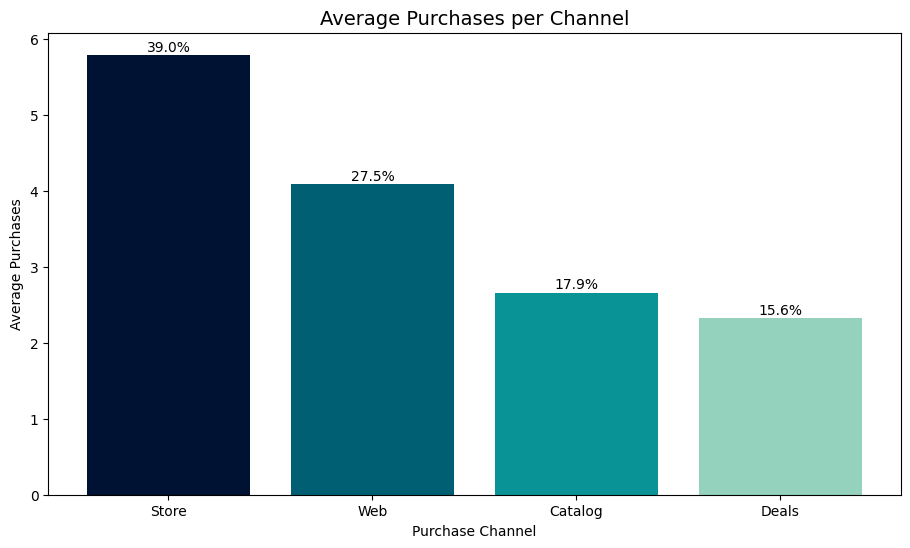

In [32]:
# Average purchases per channel
channel_avg = {
    'Store': df['NumStorePurchases'].mean(),
    'Web': df['NumWebPurchases'].mean(),
    'Catalog': df['NumCatalogPurchases'].mean(),
    'Deals': df['NumDealsPurchases'].mean()
}
total = sum(channel_avg.values())                                                 # Convert to percentages
channel_percent = {k: (v / total) * 100 for k, v in channel_avg.items()}

plt.figure(figsize=(11,6))                                                        # Create Bar Chart
bars = plt.bar(
    channel_avg.keys(),
    channel_avg.values(),
    color=['#001233','#005f73','#0a9396','#94d2bd']
)
plt.title("Average Purchases per Channel", fontsize=14)                            # Title and Labels
plt.xlabel("Purchase Channel")
plt.ylabel("Average Purchases")

# Add percentage labels on top of bars
for i, (key, value) in enumerate(channel_avg.items()):
    plt.text(
        i,
        value + 0.05,
        f"{channel_percent[key]:.1f}%",
        ha='center',
        fontsize=10
    )
plt.show()

## Total Spending by Education Level:


In [33]:
import pandas as pd
from IPython.display import display

# Data
education_spending = df.groupby('Education')['Total_Spending'].sum().sort_values(ascending=False)
education_percentage = (education_spending / education_spending.sum() * 100).round(2)

education_table = pd.DataFrame({
    'Total Spending ($)': education_spending,
    ' (%)': education_percentage
})

# Styling
styled_table = (
    education_table.style
    .format({
        'Total Spending ($)': '${:,.0f}',
        ' (%)': '{:.2f}%'
    })

    # Gradient for spending
    .background_gradient(cmap='Blues', subset=['Total Spending ($)'])

    # Bar for percentage column
    .bar(subset=[' (%)'], color='#2ec4b6')

    # Cell styling
    .set_properties(**{
        'text-align': 'center',
        'padding': '10px',
        'border': '1px solid #e6e6e6'
    })

    # Header styling (light professional blue instead of black)
    .set_table_styles([
        {'selector': 'th',
         'props': [
            ('background-color', '#4682B4'),   # soft professional blue
            ('color', 'white'),
            ('font-size', '12pt'),
            ('text-align', 'center')
         ]}
    ])
)

display(styled_table)

,Total Spending ($),(%)
Education,,
Graduation,"$698,626",51.56%
PhD,"$324,938",23.98%
Master,"$226,359",16.70%
2n Cycle,"$100,708",7.43%
Basic,"$4,417",0.33%


## Average spending by Education level on Each Product

In [34]:
products = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

# Mean spending per education
edu_result = df.groupby("Education")[products].mean().round(2)

# Rename columns
edu_result = edu_result.rename(columns={
    "MntWines": "Wines",
    "MntFruits": "Fruits",
    "MntMeatProducts": "Meat",
    "MntFishProducts": "Fish",
    "MntSweetProducts": "Sweets",
    "MntGoldProds": "Gold"
})

# Total spend (raw)
edu_result["Total Spend"] = edu_result.sum(axis=1)

# Convert product columns to %
edu_percent = edu_result.div(edu_result["Total Spend"], axis=0) * 100

# Keep total as raw value
edu_percent["Total Spend"] = edu_result["Total Spend"]

# Reorder: products first, Total LAST
edu_percent = edu_percent[["Wines", "Fruits", "Meat", "Fish", "Sweets", "Gold", "Total Spend"]]

# Format %
for col in edu_percent.columns:
    if col != "Total Spend":
        edu_percent[col] = edu_percent[col].map(lambda x: f"{x:.2f}%")

edu_percent

,Wines,Fruits,Meat,Fish,Sweets,Gold,Total Spend
Education,,,,,,,
2n Cycle,39.92%,5.83%,28.46%,9.56%,6.90%,9.33%,501.04
Basic,8.85%,13.58%,13.99%,20.86%,14.81%,27.91%,81.79
Graduation,45.86%,4.96%,28.95%,6.96%,5.06%,8.20%,619.90
Master,54.44%,3.54%,26.71%,5.25%,3.46%,6.60%,611.79
PhD,60.27%,2.95%,25.04%,3.97%,3.00%,4.76%,669.97


## The Most Valueable Customers are....

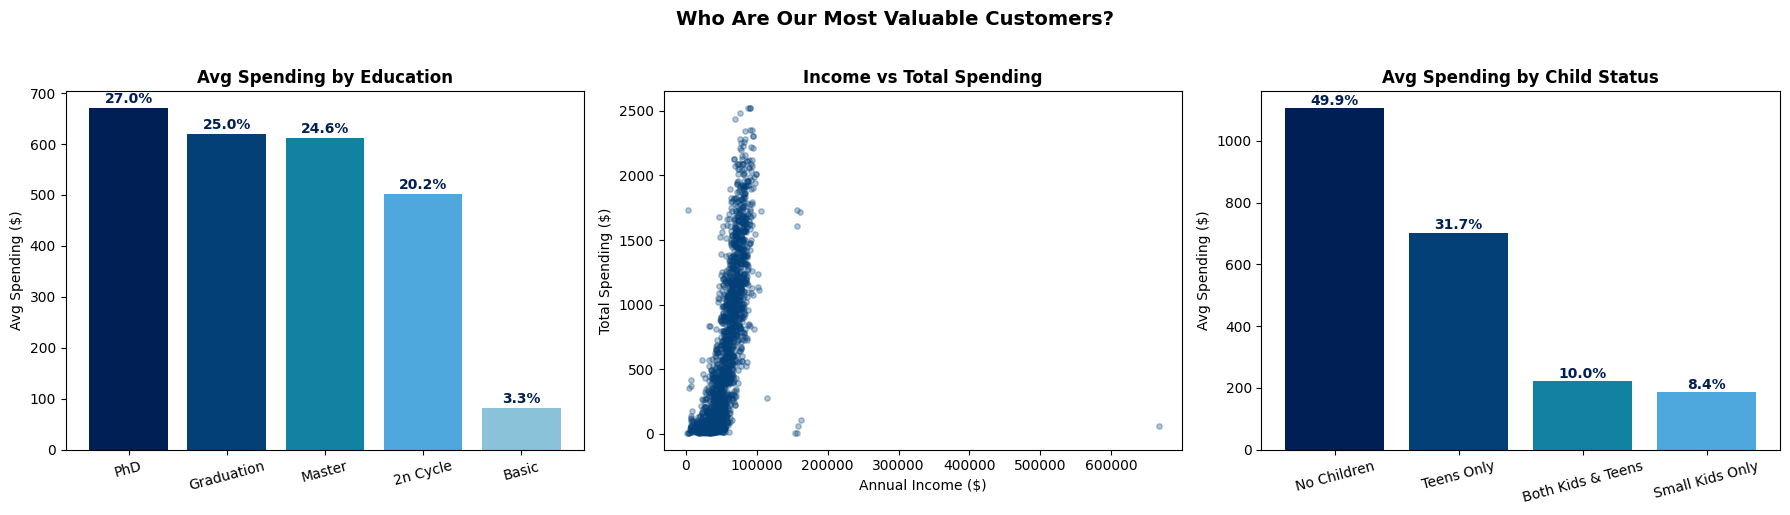

PROFILE OF TOP 20% SPENDERS:
  Avg Income   : $76,273
  Avg Age      : 47 years
  Avg Children : 0.3
  Top Education: Graduation
  Avg Spending : $1,583


In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
blue_colors = ['#001f54','#034078','#1282a2','#4ea8de','#89c2d9']
edu_spend = df.groupby('Education')['Total_Spending'].mean().sort_values(ascending=False)      # 1. Spending by Education
edu_pct = (edu_spend / edu_spend.sum() * 100).round(1)                                          # Percentage contribution
bars = axes[0].bar(
    edu_spend.index,
    edu_spend.values,
    color=blue_colors
)
axes[0].set_title('Avg Spending by Education', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Avg Spending ($)')
axes[0].tick_params(axis='x', rotation=15)

# Add percentage labels
for bar, value, pct in zip(bars, edu_spend.values, edu_pct.values):

    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 10,
        f'{pct:.1f}%',
        ha='center',
        fontsize=10,
        fontweight='bold',
        color='#001f54'
    )
axes[1].scatter(                                                                      # 2. Income vs Spending Scatter

    df['Income'],
    df['Total_Spending'],
    alpha=0.3,
    color='#034078',
    s=15
)
axes[1].set_title('Income vs Total Spending', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Annual Income ($)')
axes[1].set_ylabel('Total Spending ($)')

child_spend = df.groupby('Child_Status')['Total_Spending'].mean().sort_values(ascending=False)          # 3. Spending by Child Type

child_pct = (child_spend / child_spend.sum() * 100).round(1)                                          # Percentage contribution
bars3 = axes[2].bar(
    child_spend.index,
    child_spend.values,
    color=['#001f54','#034078','#1282a2','#4ea8de']
)
axes[2].set_title('Avg Spending by Child Status', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Avg Spending ($)')
axes[2].tick_params(axis='x', rotation=15)

# Add percentage labels
for bar, value, pct in zip(bars3, child_spend.values, child_pct.values):

    axes[2].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 10,
        f'{pct:.1f}%',
        ha='center',
        fontsize=10,
        fontweight='bold',
        color='#001f54'
    )
plt.suptitle(
    'Who Are Our Most Valuable Customers?',
    fontsize=14,
    fontweight='bold',
    y=1.02
)
plt.tight_layout()
plt.show()

top20 = df[df['Total_Spending'] >= df['Total_Spending'].quantile(0.80)]            # Profile of Top 20% Spenders

print('PROFILE OF TOP 20% SPENDERS:')
print(f'  Avg Income   : ${top20["Income"].mean():,.0f}')
print(f'  Avg Age      : {top20["Age"].mean():.0f} years')
print(f'  Avg Children : {top20["Total_Childerns"].mean():.1f}')
print(f'  Top Education: {top20["Education"].mode()[0]}')
print(f'  Avg Spending : ${top20["Total_Spending"].mean():,.0f}')

## Total Spending Vs Marital Status




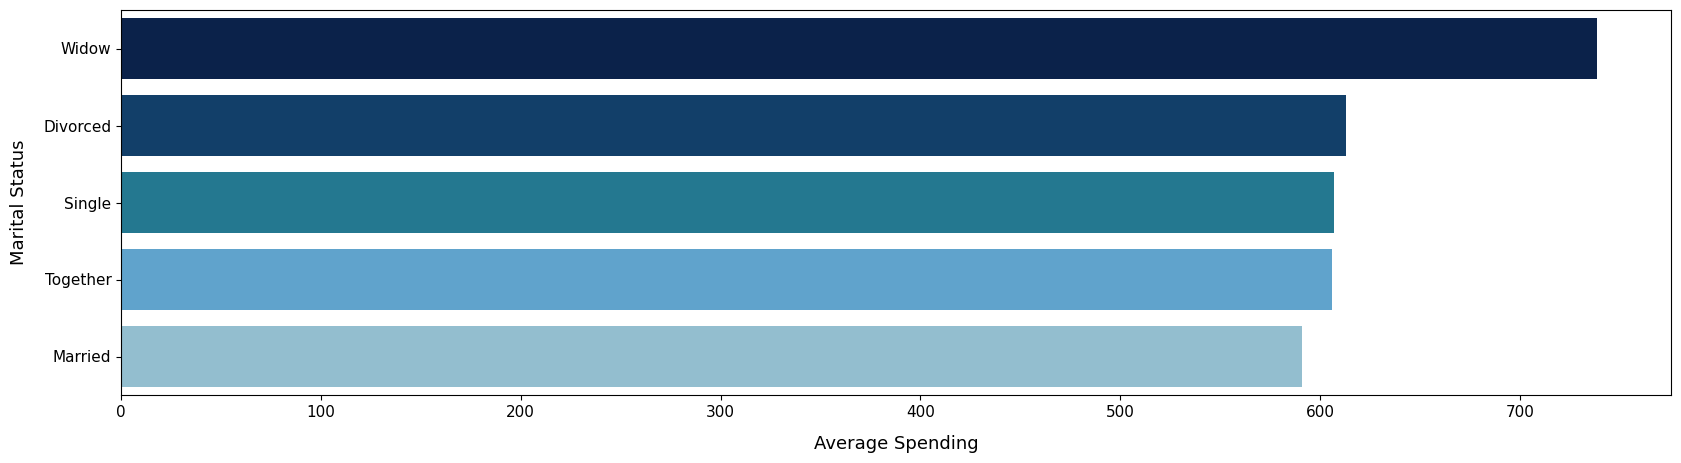

In [36]:
maritalspending = df.groupby('Marital_Status')['Total_Spending'].mean().sort_values(ascending=False)
maritalspending_df = pd.DataFrame(list(maritalspending.items()), columns=['Marital Status', 'Average Spending'])

plt.figure(figsize=(20,5))

colors = ["#001f54","#034078","#1282a2","#4ea8de","#89c2d9","#caf0f8"]
sns.barplot(
    data=maritalspending_df,
    x="Average Spending",
    y="Marital Status",
    palette= colors
)
plt.xticks( fontsize=11)
plt.yticks( fontsize=11)
plt.title = ('Total Spending Vs Marital Status')
plt.xlabel('Average Spending', fontsize=13, labelpad=11)
plt.ylabel('Marital Status', fontsize=13, labelpad=11);

## Top Revenue Generating Products

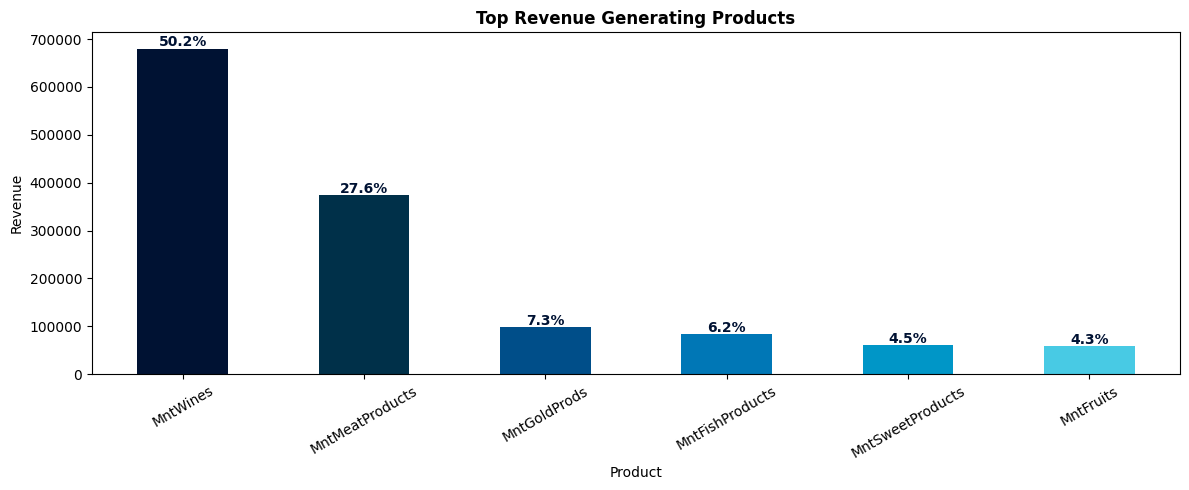

In [ ]:
products = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]
#  Calculate Revenue
sales = df[products].sum()
result = sales.reset_index()
result.columns = ["Product", "Revenue"]

#  Calculate Percentage Contribution
result["Revenue %"] = (
    result["Revenue"] / result["Revenue"].sum() * 100
).round(2)

# ── Sort Highest to Lowest
result = result.sort_values(by="Revenue", ascending=False)
# ── Colors
Blue_Colors = [
    '#001233', '#003049', '#004e89',
    '#0077b6', '#0096c7', '#48cae4'
]
ax = result.plot(
    kind="bar",
    x="Product",
    y="Revenue",
    figsize=(12,5),
    color=Blue_Colors,
    legend=False
)
plt.title("Top Revenue Generating Products", fontsize=12, fontweight='bold')
plt.ylabel("Revenue")
plt.xticks(rotation=30)

#  Add Percentage Labels
for i, (value, pct) in enumerate(zip(result["Revenue"], result["Revenue %"])):
    ax.text(
        i,
        value + 5000,              # space above bar
        f'{pct:.1f}%',
        ha='center',
        fontsize=10,
        fontweight='bold',
        color='#001233'
    )

plt.tight_layout()
plt.show()

In [52]:
import importlib
importlib.reload(plt)

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

## Correlation Heatmap


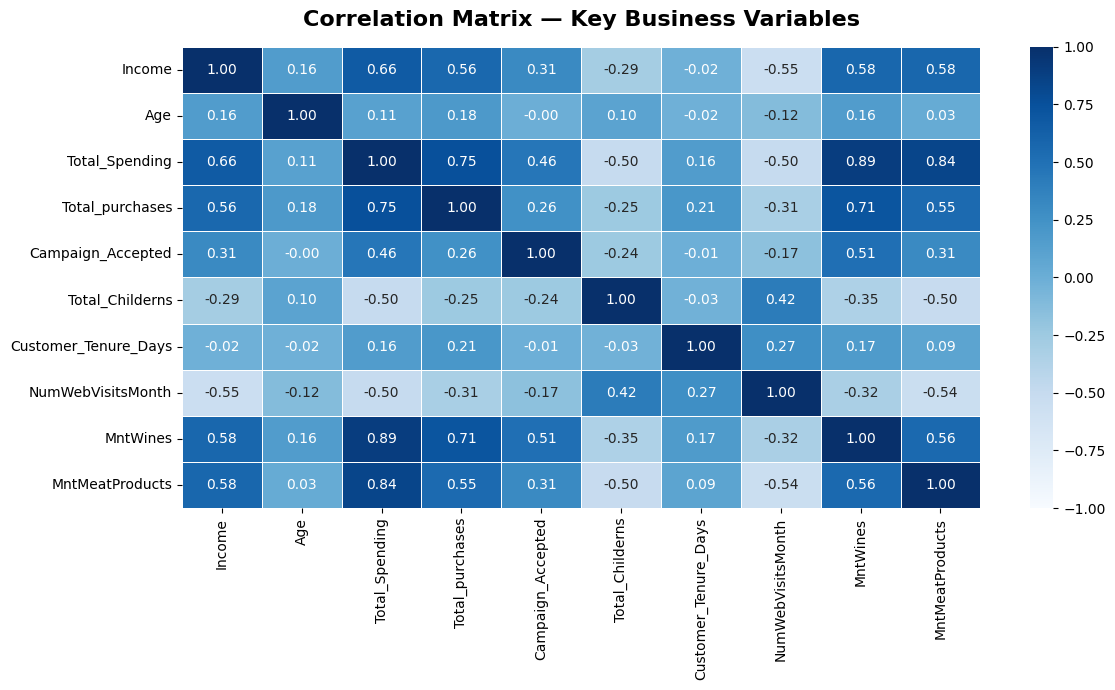

 KEY INSIGHT: Income & Total_Spending have the STRONGEST positive correlation.
   → Targeting HIGH-income customers = significantly higher revenue.


In [53]:
corr_cols = ['Income', 'Age', 'Total_Spending', 'Total_purchases',                        # Final lifetime value in dollars

             'Campaign_Accepted', 'Total_Childerns', 'Customer_Tenure_Days',
             'NumWebVisitsMonth', 'MntWines', 'MntMeatProducts']

corr_matrix = df[corr_cols].corr()                                                         #  calculate all correlations

plt.figure(figsize=(12, 7))
sns.heatmap(                                                                                #  # draw the coloured grid


    corr_matrix, annot=True, fmt='.2f', cmap='Blues',
    linewidths=0.5, vmin=-1, vmax=1, annot_kws={'size': 10}
)
plt.title('Correlation Matrix — Key Business Variables', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print(' KEY INSIGHT: Income & Total_Spending have the STRONGEST positive correlation.')
print('   → Targeting HIGH-income customers = significantly higher revenue.')

## RFM Customer Segmentation


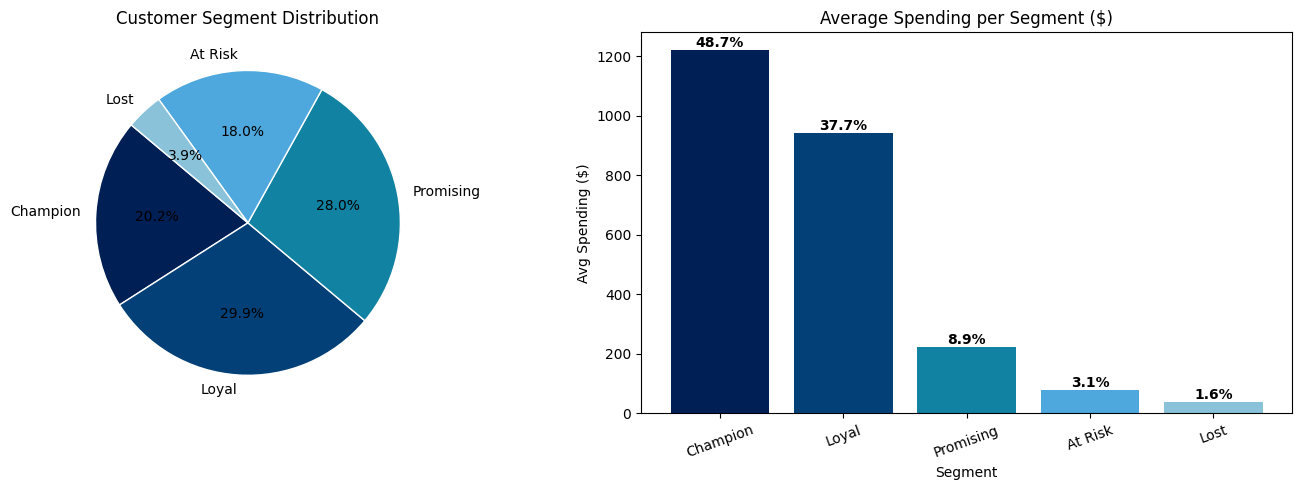

In [54]:
# STEP 1: Create RFM table
rfm = df[['"ID', 'Customer_Tenure_Days', 'Total_purchases', 'Total_Spending']].copy()
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# STEP 2: RFM Scoring
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'], 4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4])

rfm['RFM_Score'] = (
    rfm['R_Score'].astype(int) +
    rfm['F_Score'].astype(int) +
    rfm['M_Score'].astype(int)
)

def segment(score):
    if score >= 10:
        return 'Champion'
    elif score >= 8:
        return 'Loyal'
    elif score >= 6:
        return 'Promising'
    elif score >= 4:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm['RFM_Score'].apply(segment)

# STEP 4: Visualization setup
segments = ['Champion', 'Loyal', 'Promising', 'At Risk', 'Lost']
colors = ['#001f54', '#034078', '#1282a2', '#4ea8de', '#89c2d9']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

segment_counts = rfm['Segment'].value_counts().reindex(segments).dropna()

# PIE CHART
axes[0].pie(
    segment_counts.values,
    labels=segment_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white'}
)
axes[0].set_title("Customer Segment Distribution")

# BAR CHART
avg_spending = rfm.groupby('Segment')['Monetary'].mean().reindex(segments).dropna()

bars = axes[1].bar(avg_spending.index, avg_spending.values, color=colors)

axes[1].set_title("Average Spending per Segment ($)")
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("Avg Spending ($)")
axes[1].tick_params(axis='x', rotation=20)

# Add ONLY percentages on bars
total = avg_spending.sum()

for bar in bars:
    pct = (bar.get_height() / total) * 100

    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{pct:.1f}%',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

## Customer Lifetime Value (CLV)


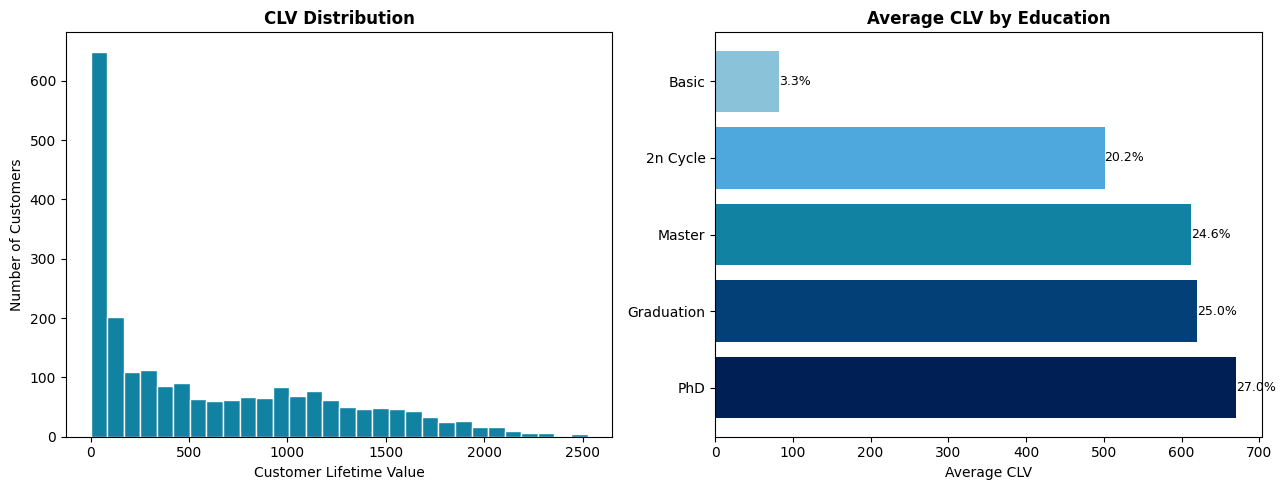


INSIGHT:
PhD and Masters customers have the highest CLV.


In [55]:
# Calculate CLV
df['CLV'] = (
    df['Total_Spending'] /
    df['Total_purchases'].replace(0, 1)
) * df['Total_purchases']

# CLV by Education
clv_education = (
    df.groupby('Education')['CLV']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(13,5))

# Histogram
plt.subplot(1,2,1)

plt.hist(
    df['CLV'],
    bins=30,
    color='#1282a2',
    edgecolor='white'
)

plt.title("CLV Distribution",fontsize=12, fontweight='bold')
plt.xlabel("Customer Lifetime Value")
plt.ylabel("Number of Customers")

# Bar Chart
plt.subplot(1,2,2)

bars = plt.barh(
    clv_education.index,
    clv_education.values,
    color=['#001f54','#034078','#1282a2','#4ea8de','#89c2d9']
)

plt.title("Average CLV by Education",fontsize=12, fontweight='bold')
plt.xlabel("Average CLV")

# Add percentages on bars (ONLY CHANGE)
total = clv_education.sum()

for bar in bars:
    pct = (bar.get_width() / total) * 100

    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f'{pct:.1f}%',
        va='center',
        ha='left',
        fontsize=9
    )

plt.tight_layout()
plt.show()

# Insight
print("\nINSIGHT:")
print("PhD and Masters customers have the highest CLV.")

## Comapign Acceptance Rate:

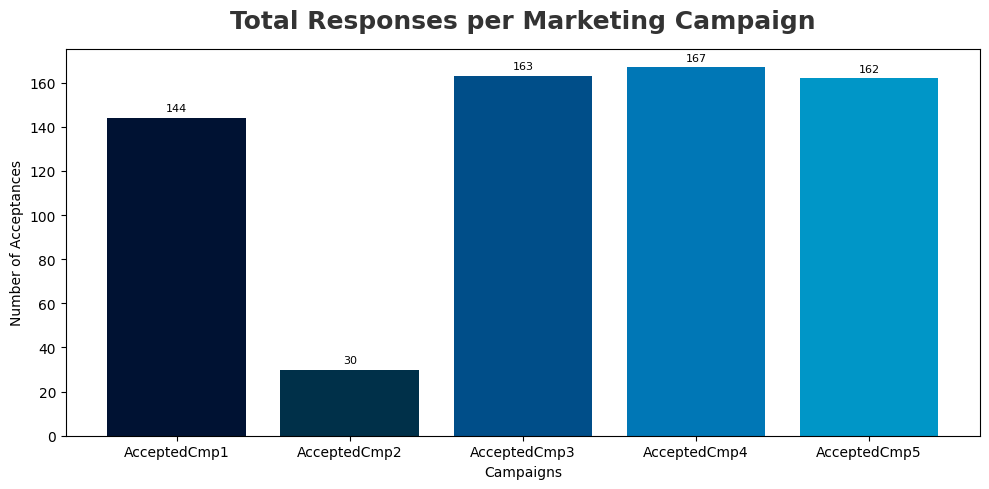

In [56]:
cmp1 = df['AcceptedCmp1'].sum()
cmp2 = df['AcceptedCmp2'].sum()
cmp3 = df['AcceptedCmp3'].sum()
cmp4 = df['AcceptedCmp4'].sum()
cmp5 = df['AcceptedCmp5'].sum()


# Put the values into lists for the chart
campaigns = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
             'AcceptedCmp4', 'AcceptedCmp5']

values = [cmp1, cmp2, cmp3, cmp4, cmp5]

Blue_Colors = [
    '#001233', '#003049', '#004e89', '#0077b6',
    '#0096c7', '#48cae4', '#90e0ef', '#ade8f4'
]
# Create the bar chart

plt.figure(figsize=(10, 5))
plt.bar(campaigns, values, color=Blue_Colors)

plt.title("Total Responses per Marketing Campaign",fontsize=18, fontweight='bold', pad=15, color='#333333')
plt.xlabel("Campaigns")
plt.ylabel("Number of Acceptances")

# Add the number on top of each bar
for i in range(len(campaigns)):
    plt.text(i, values[i] + 3, str(values[i]), ha='center', fontsize=8)

plt.tight_layout()
plt.savefig("campaign_responses.png", dpi=150)
plt.show()

## Campaign Acceptance Rate by Marital Status:

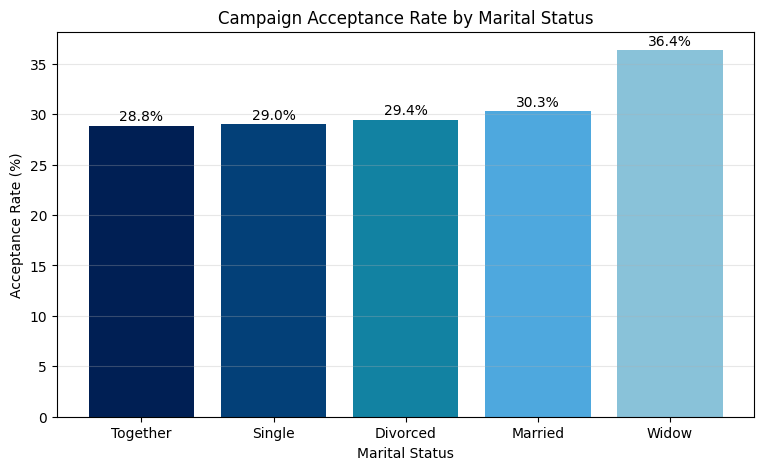

In [57]:
# Average Campaign Acceptance by Marital Status

avg_campaigns_by_marital = (
    df.groupby('Marital_Status')['Campaign_Accepted']
    .mean()
    .sort_values()
    .reset_index()
)
avg_campaigns_by_marital['Campaign_Accepted'] = (                                # Convert to percentage
    avg_campaigns_by_marital['Campaign_Accepted'] * 100
).round(2)
avg_campaigns_by_marital.columns = [                                             # Rename columns
    "Marital Status",
    "Campaign Acceptance (%)"
]
# ── DRAW BAR CHART
plt.figure(figsize=(9,5))

bars = plt.bar(
    avg_campaigns_by_marital["Marital Status"],
    avg_campaigns_by_marital["Campaign Acceptance (%)"],
    color=['#001f54', '#034078', '#1282a2', '#4ea8de', '#89c2d9']
)
for bar in bars:                                                       # ADD PERCENTAGE LABELS ON TOP OF BARS
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f'{height:.1f}%',
        ha='center'
    )

plt.title("Campaign Acceptance Rate by Marital Status")                 # TITLES AND LABELS

plt.xlabel("Marital Status")

plt.ylabel("Acceptance Rate (%)")

plt.grid(axis='y', alpha=0.3)

plt.show()

## Campaign Acceptance Rate by Education:

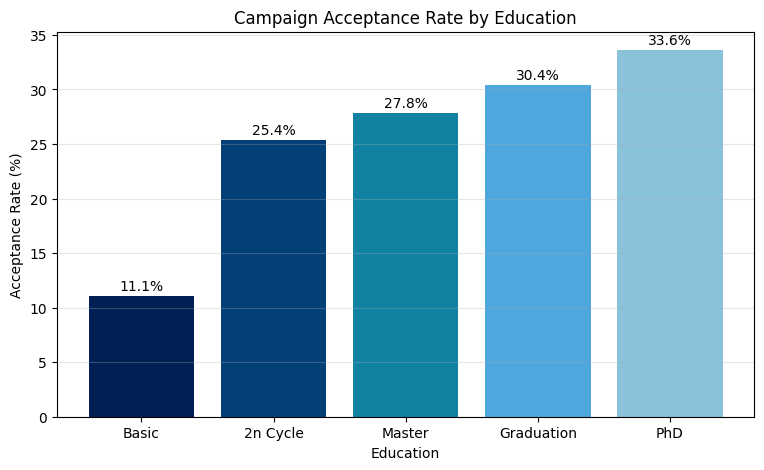

In [58]:
import matplotlib.pyplot as plt

# ── GRAPH 1: Campaign Acceptance by Education ─────────────────────────

avg_campaigns_by_education = (
    df.groupby('Education')['Campaign_Accepted']
    .mean()
    .sort_values()
    .reset_index()
)

# Convert to percentage
avg_campaigns_by_education['Campaign_Accepted'] = (
    avg_campaigns_by_education['Campaign_Accepted'] * 100
).round(2)

# DRAW GRAPH
plt.figure(figsize=(9,5))

bars = plt.bar(
    avg_campaigns_by_education['Education'],
    avg_campaigns_by_education['Campaign_Accepted'],
    color=['#001f54','#034078','#1282a2','#4ea8de','#89c2d9']
)

# ADD PERCENTAGES
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f'{height:.1f}%',
        ha='center'
    )

plt.title("Campaign Acceptance Rate by Education")

plt.xlabel("Education")

plt.ylabel("Acceptance Rate (%)")

plt.grid(axis='y', alpha=0.3)

plt.show()

## Campaign Acceptance Rate by Income Group:

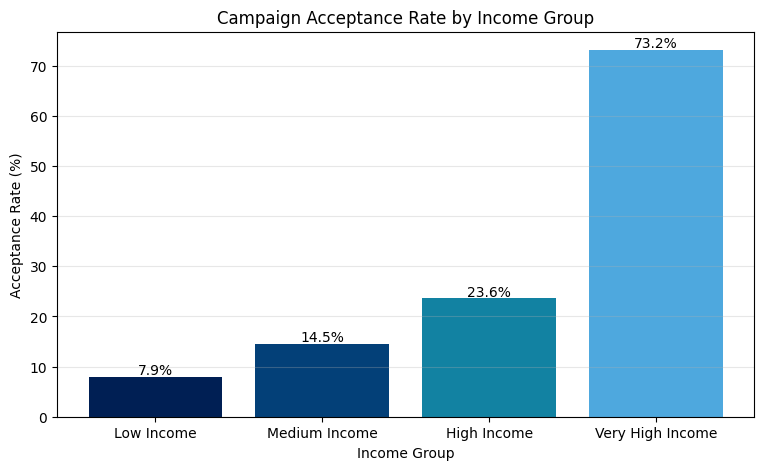

In [59]:
#  GRAPH 3: Campaign Acceptance by Income Group

# CREATE INCOME GROUPS
df['Income_Group'] = pd.qcut(
    df['Income'],
    q=4,
    labels=['Low Income', 'Medium Income', 'High Income', 'Very High Income']
)
avg_campaigns_by_income = (                                            # CALCULATE AVERAGES
    df.groupby('Income_Group')['Campaign_Accepted']
    .mean()
    .reset_index()
)
avg_campaigns_by_income['Campaign_Accepted'] = (                      # Convert to percentage
    avg_campaigns_by_income['Campaign_Accepted'] * 100
).round(2)

# DRAW GRAPH
plt.figure(figsize=(9,5))

bars = plt.bar(
    avg_campaigns_by_income['Income_Group'],
    avg_campaigns_by_income['Campaign_Accepted'],
    color=['#001f54','#034078','#1282a2','#4ea8de']
)

# ADD LABELS
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f'{height:.1f}%',
        ha='center'
    )

plt.title("Campaign Acceptance Rate by Income Group")

plt.xlabel("Income Group")

plt.ylabel("Acceptance Rate (%)")

plt.grid(axis='y', alpha=0.3)

plt.show()

# Conclusion Matrix

---

| # | Analysis Area | Key Finding | Business Impact | Recommendation |
|---|---------------|-------------|-----------------|----------------|
| 1 | **High-Value Customers** | Customers aged 40–65 with high income and higher education spend the most, especially on wines and meat products. Income and total spending share the strongest positive correlation in the dataset. | These customers contribute the largest share of company revenue and profitability. | Focus premium marketing campaigns and personalised offers on this segment. Use income-based audience targeting when allocating ad spend. |
| 2 | **Customer Loyalty (RFM)** | The top 10% of customers (Champions + Loyal tiers) generate a disproportionate share of total revenue. Champions show the highest average spending per segment. | Losing even a small number of loyal high-value customers can significantly reduce total profits. | Introduce a VIP loyalty programme with exclusive discounts, rewards, and early-access offers to protect high-CLV relationships. |
| 3 | **Campaign Performance** | Campaign 2 had the lowest acceptance rate across all five campaigns. Higher-income and more-educated customers are significantly more likely to accept any campaign. | Ineffective campaigns waste marketing budget and lower overall ROI. | Audit Campaign 2's targeting, messaging, and timing. Apply A/B testing before future full launches and reallocate budget toward high-income segments. |
| 4 | **Education & Income Influence** | Higher education and income levels are strongly linked to higher campaign acceptance rates and total spending. PhD and Master-level customers show the highest CLV. | Marketing efficiency improves when campaigns are directed at the most responsive groups. | Allocate more of the marketing budget toward highly educated and high-income customer segments. |
| 5 | **Product Preferences** | Wines and meat products drive the highest spending among premium customers. Gold, fruit, and sweet products contribute less revenue overall. | Premium products generate higher revenue and increase customer lifetime value. | Increase promotion and cross-selling of wines and meat. Bundle complementary premium categories to raise the average basket value. |
| 6 | **Family Customers** | Customers with children (Kidhome + Teenhome > 0) spend less on average than childless customers, but still represent a sizeable segment with long-term potential. | This segment may have tighter budgets but cannot be ignored given its size. | Create affordable bundles, family-oriented promotions, and value-based offers to maintain engagement without eroding margin. |
| 7 | **Sales Channel Strategy** | Different customer groups show different spending and response patterns across channels. A single marketing strategy does not work effectively for all customers. | Misaligned channel investment reduces return on spend. | Use customer segmentation to deliver targeted, personalised marketing across the most effective channels for each group. |
